In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import scipy.integrate as integrate

# Part I

1. (15 pts.) Create two functions in Python that will generate the weight vectors for the Trapezoidal rule and Simpson’s rule. The functions should ask a, b, and N as inputs where a and b are the lower and upper limits of the integration, respectively and N is the number of data points. Note that for Simpson’s rule the code should prompt an error whenever N is even. Now print the following outputs using the function created:



In [77]:
"""
weight generator for respective functions
"""

def trap_weight(a,b,N):
    array = []
    h = (b - a) / (N - 1) # step size
    for i in range(1,N-1):
        array.append(h)
    array.insert(0,(h/2))
    array.append((h/2))
    return array

               
def simp_weight(a,b,N):
    array = []
    i = 0
    if (N % 2) == 0:
        print("Error: Simpson's rule does not accepet even data points")
    else:
        h = (b - a) / (N - 1) # step size
        while i != (N-2):
            if (i % 2) == 0:
                array.append(4*h/3)
                i += 1
            else:
                array.append(2*h/3)
                i += 1
        array.insert(0,(h/3))
        array.append((h/3))
        return array
    
def simp_weight_38(a,b,N):
    array = []
    i = 1
    if ((N-1)%3) ==  0:
        print("Error: Simpson's rule does not accept middle points not of 2,5,9 ...")
    else:
        h = (b - a) / (N - 1) # step size
        while i != (N-2):
            if i % 3 != 0:
                array.append(3*)
                i += 1
            else:
                array.append(2*)
                i += 1
        array.insert(0,((3*h)/8)) 
        
        array.append((3*h)/8)
        return array
    

SyntaxError: invalid syntax (<ipython-input-77-bc2bcfffb683>, line 42)

- a. Print the weight vector for the trapezoidal rule when a=0, b=6, and N=7.


In [65]:
print(trap_weight(0,6,7))

[0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5]


- b. Print the weight vector for the Simpson’s rule when a=0, b=18, and N=7.

In [66]:
print(simp_weight_38(0,12,13))

Error: Simpson's rule does not accept points not 5
None


# Part 2. (20 pts.)

### a. Evaluate the integration:

### $$\int_{0}^{1} e^{-t} \,dx $$

numerically using the trapezoidal rule, Simpson’s rule, and Gaussian quadrature for 𝑁=(3,203,403,...,10003). For the trapezoidal and Simpson’s rules utilize the weight generating function from part 1, note that the numerical integration using these rules can simply be executed by a dot product of two matrices. For the Gaussian quadrature use the built-in function integrate.quadrature from scipy. This function can utilize the Lambda Python function which will represent a small anonymous mathematical function. For more details, please see Ref. [2] and Ref. [3].

Note that the exact value of the integration is:

### $$\int_{0}^{1} e^{-t} \,dx = 1-e^{-1} $$

In [19]:
# integrand function

def func(t):
    return 1/np.exp(t)

# array generating function ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

def N_gen(N): # generates evenly spaced array that follows the spacing format of b-a/N-1
    return np.linspace(0,1,N)

# sum functions - collapses it to a single sum value ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

def dotter(a,b): # returns dot product
    return np.dot(a,b)

# output ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
k = 3
f = lambda t : 1/np.exp(t) 

while k != 1203:
    print("N =",k,"trapezoidal sum:", dotter(trap_weight(0,1,k), func(N_gen(k))),
          "N =",k,"simpsons sum:", dotter(simp_weight(0,1,k), func(N_gen(k))),
          "N =",k,"gauss sum:", integrate.quadrature(f, 0, 1, maxiter=k)[0])  
    k += 200

N = 3 trapezoidal sum: 0.6452351901491773 N = 3 simpsons sum: 0.6323336800036626 N = 3 gauss sum: 0.6321202556640678
N = 203 trapezoidal sum: 0.6321218497973774 N = 203 simpsons sum: 0.6321205588306669 N = 203 gauss sum: 0.6321205588283172
N = 403 trapezoidal sum: 0.6321208847902158 N = 403 simpsons sum: 0.6321205588286922 N = 403 gauss sum: 0.6321205588283172
N = 603 trapezoidal sum: 0.6321207041821157 N = 603 simpsons sum: 0.6321205588285844 N = 603 gauss sum: 0.6321205588283172
N = 803 trapezoidal sum: 0.6321206407259212 N = 803 simpsons sum: 0.6321205588285661 N = 803 gauss sum: 0.6321205588283172
N = 1003 trapezoidal sum: 0.6321206112951936 N = 1003 simpsons sum: 0.6321205588285611 N = 1003 gauss sum: 0.6321205588283172


### b. Compute the relative error 𝜖 = |(numerical-exact)∕exact| in each method and value of N. Graph the log-log plot of 𝜖 vs. N for each method. 

In [41]:
array1, array2, array3, N = [], [], [], []

# relative error function
def err(a):
    return abs((a-(1-np.exp(-1)))/(1-np.exp(-1)))

k = 3
while k != 5003:
    array1.append(dotter(trap_weight(0,1,k), func(N_gen(k))))
    array2.append(dotter(simp_weight(0,1,k), func(N_gen(k))))
    array3.append(integrate.quadrature(func, 0, 1, maxiter=k)[0])
    N.append(k)
    k += 10
    
# data frame to check relative error values from 1-1003
trap_err, simp_err, gauss_err = err(array1),err(array2),err(array3)
j = {'N':N[0:101],'trap_rel_err': trap_err[0:101],'simp_rel_err': simp_err[0:101], 'gauss_rel_err': gauss_err[0:101]}
df = pd.DataFrame(j)
print(df)

C:\Users\ASUS\anaconda3\lib\site-packages\scipy\integrate\_quadrature.py:259: AccuracyWarning: maxiter (3) exceeded. Latest difference = 1.414961e-04
  warnings.warn(


        N  trap_rel_err  simp_rel_err  gauss_rel_err
0       3  2.074704e-02  3.371527e-04   4.795992e-07
1      13  5.786367e-04  2.676970e-07   3.804248e-13
2      23  1.721704e-04  2.370991e-08   3.804248e-13
3      33  8.137888e-05  5.297575e-09   3.804248e-13
4      43  4.724067e-05  1.785258e-09   3.804248e-13
..    ...           ...           ...            ...
96    963  9.004687e-08  6.322849e-15   3.804248e-13
97    973  8.820358e-08  6.322849e-15   3.804248e-13
98    983  8.641632e-08  5.971580e-15   3.804248e-13
99    993  8.468284e-08  5.620310e-15   3.804248e-13
100  1003  8.300100e-08  5.444676e-15   3.804248e-13

[101 rows x 4 columns]


Text(0, 0.5, '$\\epsilon\\_approx$')

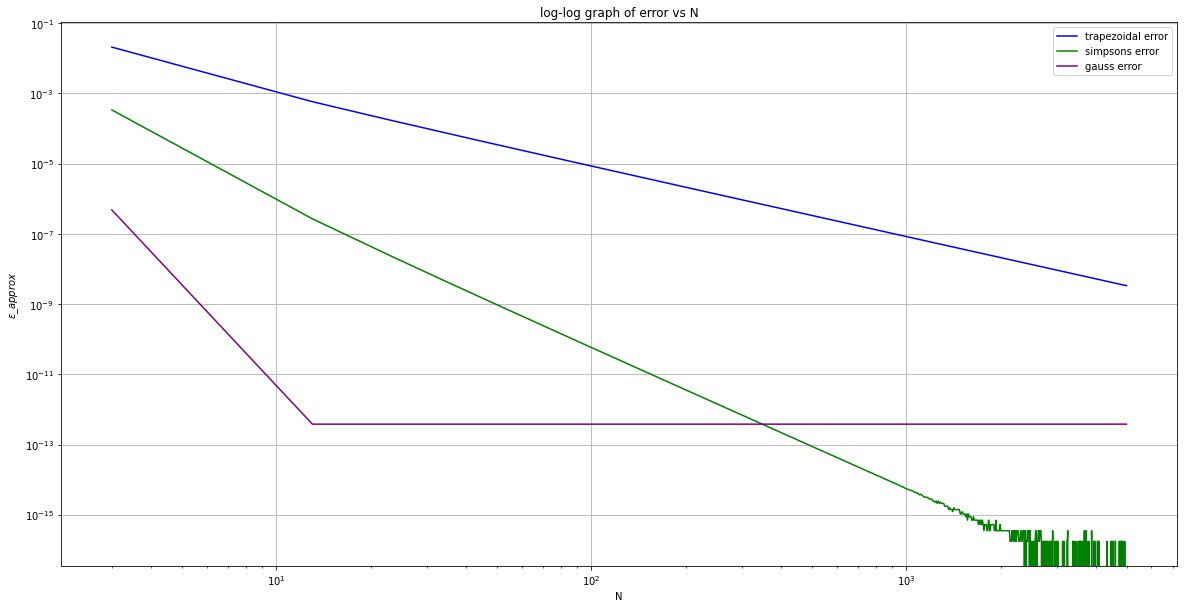

In [43]:
fig, (ax1) = plt.subplots(1,figsize=(20,10))

ax1.loglog(N,trap_err, label = 'trapezoidal error', color='blue')
ax1.loglog(N,simp_err, label = 'simpsons error', color="green")
ax1.loglog(N,gauss_err, label = 'gauss error', color="purple")
ax1.set_title('log-log graph of error vs N')
ax1.grid()
ax1.legend()
ax1.set_xlabel('N')
ax1.set_ylabel('$\epsilon\_approx$')

The reason for the prominent squiggles is probably because the loop I used uses +10 instead of +100

### Questions (9 pts.)

In [44]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
m = {'N':N,'trap_rel_err': trap_err,'simp_rel_err': simp_err, 'gauss_rel_err': gauss_err}
dm = pd.DataFrame(m)
print(dm)
np.concatenate(np.where(dm.gauss_rel_err == simp_rel_err)).tolist()

        N  trap_rel_err  simp_rel_err  gauss_rel_err
0       3  2.074704e-02  3.371527e-04   4.795992e-07
1      13  5.786367e-04  2.676970e-07   3.804248e-13
2      23  1.721704e-04  2.370991e-08   3.804248e-13
3      33  8.137888e-05  5.297575e-09   3.804248e-13
4      43  4.724067e-05  1.785258e-09   3.804248e-13
5      53  3.081835e-05  7.597925e-10   3.804248e-13
6      63  2.167871e-05  3.759647e-10   3.804248e-13
7      73  1.607505e-05  2.067224e-10   3.804248e-13
8      83  1.239339e-05  1.228754e-10   3.804248e-13
9      93  9.845601e-06  7.754781e-11   3.804248e-13
10    103  8.009727e-06  5.132415e-11   3.804248e-13
11    113  6.643273e-06  3.530609e-11   3.804248e-13
12    123  5.598847e-06  2.507747e-11   3.804248e-13
13    133  4.782671e-06  1.829938e-11   3.804248e-13
14    143  4.132774e-06  1.366385e-11   3.804248e-13
15    153  3.606876e-06  1.040759e-11   3.804248e-13
16    163  3.175327e-06  8.066199e-12   3.804248e-13
17    173  2.816836e-06  6.347614e-12   3.8042

NameError: name 'simp_rel_err' is not defined

### 1. Which method can generate the most accurate result and in how many data points did it occurred?

For N = 1003, the Simpsons method can generate the most accurate reults with a relative error of 5.444676e-15( compared to the relative error of Trapezoidal:8.300100e-08 and Gaussian:3.804248e-13). It took approximately 1003 data points before it reached its peak accuracy

### 2. Which method is the most efficient (not computationally expensive) and has relatively high accuracy?

The Gaussian method is the most efficient as the graph takes little N before it reaches an flatline error of 3.804248e-13 and has relatively high accuracy within that short amount of iteration.

### 3. Approximate at what values of N  will give you the best numerical approximation of the integration for Simpson’s rule and the built-in Gaussian Quadrature.

For the Gaussian rule approximately around the the 13th step(approximately around or near that step), as seen in the dataframe, will give you the best numerical approximation

for the Simpson's rule approximately around if we limit the step to 1003 then we could say that the best numerical approximations are at values of N = 1003. However, if we go beyond (as seen in the graph), we see that the best nuumerical approximation for the Simpson's rule start at around N = 1993 where the values start plateuing at 3.512694e-16 then fluctuates to 1.756347e-16 and back to 3.512694e-16 until at around N= 2373 where the error spikes downwards to 0.000000e+00